# Diabetes Prediction — Machine Learning Classification Project

## 1. Introduction

### Problem Statement
Diabetes is a chronic disease that, if detected early, can be managed far more
effectively. In this notebook we treat diabetes prediction as a **binary
classification problem**:

> Given a patient's medical measurements, predict whether the patient has
> diabetes (`Outcome = 1`) or not (`Outcome = 0`).

### Dataset
We use the **Pima Indians Diabetes Dataset**, originally published by the
National Institute of Diabetes and Digestive and Kidney Diseases. It contains
diagnostic measurements for **768 female patients** of Pima Indian heritage,
aged 21 and older.

### Goal of this Notebook
1. Understand and explore the data.
2. Build a clean, reusable preprocessing pipeline.
3. Train **multiple classification algorithms** using a single reusable
   training/evaluation loop (no repeated, copy-pasted code per model).
4. Compare all models on Accuracy, Precision, Recall, F1-score and ROC-AUC.
5. **Automatically** select the best model based on evaluation metrics
   (no manual "eyeballing" of the winner).
6. Analyze the winning model and use it to predict on a new patient.

This notebook is written to be read top-to-bottom like a tutorial — every
important code cell is preceded by a short Markdown explanation of *what* we
are doing, *why* we are doing it, and *what result we expect*.

## 2. Import Libraries

We import everything we need up front:

- **pandas / numpy** — data loading and manipulation
- **matplotlib / seaborn** — visualization
- **scikit-learn** — preprocessing, models, evaluation metrics
- **xgboost** — gradient-boosted trees (installed below if not already
  available)

Grouping imports in one place (instead of scattering `import` statements
throughout the notebook) makes dependencies explicit and the notebook easier
to re-run from scratch.

In [1]:
# Install xgboost if it isn't already available in this environment
import importlib
if importlib.util.find_spec("xgboost") is None:
    import sys
    !{sys.executable} -m pip install -q xgboost

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

import joblib

# Consistent plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

The original notebook loaded the data from a Kaggle-specific path
(`/kaggle/input/...`), which only works inside a Kaggle environment. To keep
this notebook portable and runnable anywhere, we look for a local
`diabetes.csv` file first, and fall back to downloading the well-known Pima
Indians Diabetes dataset if it isn't found.

**Expected result:** a DataFrame with 768 rows and 9 columns (8 medical
features + 1 target column, `Outcome`).

In [3]:
DATA_PATH = "diabetes.csv"

COLUMN_NAMES = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
    "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

import os

candidate_paths = [
    DATA_PATH,
    "/kaggle/input/datasets/sofonyasmebratu/diabates-file/diabetes.csv",
]

df = None
for path in candidate_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"Loaded dataset from: {path}")
        break

if df is None:
    # Fall back: download the original Pima Indians Diabetes dataset
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    df = pd.read_csv(url, header=None, names=COLUMN_NAMES)
    df.to_csv(DATA_PATH, index=False)
    print(f"Local file not found. Downloaded dataset and saved to: {DATA_PATH}")

df.head()

Loaded dataset from: diabetes.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 4. Data Understanding

Before touching the data, we need to understand its structure: how many rows
and columns it has, what type each feature is, whether there are missing or
duplicate values, and how the target class is distributed.

### Feature descriptions

| Feature | Description |
|---|---|
| `Pregnancies` | Number of times pregnant |
| `Glucose` | Plasma glucose concentration (2-hour oral glucose tolerance test) |
| `BloodPressure` | Diastolic blood pressure (mm Hg) |
| `SkinThickness` | Triceps skinfold thickness (mm) |
| `Insulin` | 2-hour serum insulin (mu U/ml) |
| `BMI` | Body mass index (weight in kg / (height in m)^2) |
| `DiabetesPedigreeFunction` | A function that scores the likelihood of diabetes based on family history |
| `Age` | Age in years |
| `Outcome` | Target — 1 = diabetes, 0 = no diabetes |

In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (768, 9)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [7]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


**Note:** `df.isnull().sum()` reports **zero** missing values — but that
is misleading. Several medical measurements (`Glucose`, `BloodPressure`,
`SkinThickness`, `Insulin`, `BMI`) contain the value **0**, which is not
physiologically possible (e.g., a blood pressure of 0). These zeros are
almost certainly missing values that were encoded as 0 rather than `NaN`. We
address this properly in the Data Preprocessing section.

In [8]:
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero_counts = (df[cols_with_invalid_zeros] == 0).sum()
print("Number of biologically-invalid zero values per column:")
print(zero_counts)

Number of biologically-invalid zero values per column:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [9]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


In [10]:
print(df["Outcome"].value_counts())
print()
print(df["Outcome"].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")

Outcome
0    500
1    268
Name: count, dtype: int64

Outcome
0    65.1 %
1    34.9 %
Name: proportion, dtype: str


**Expected result / insight:** roughly **65% of patients do not have
diabetes** and **35% do** — a moderate class imbalance. This matters later:
accuracy alone can be misleading, so we will also rely on Precision, Recall,
F1-score and ROC-AUC, and use `class_weight='balanced'` (or an equivalent)
where available.

## 5. Exploratory Data Analysis (EDA)

Now we visualize the data to understand feature distributions, relationships
with the target, and correlations between features.

### 5.1 Target Class Distribution

**What:** Count of patients with vs. without diabetes.
**Why:** Confirms the class imbalance noted above and justifies the metrics
and model settings we use later.

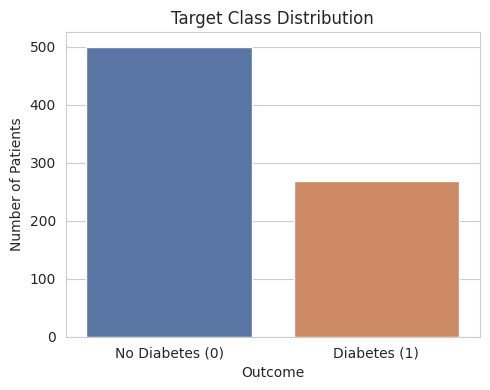

In [11]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="Outcome", data=df, palette=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"])
plt.title("Target Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### 5.2 Feature Distributions

**What:** Histogram of every numeric feature.
**Why:** Reveals skewness and the suspicious spike of zero-values in
`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` mentioned
earlier.
**Expected result:** `Insulin` and `SkinThickness` should show a large spike
at 0, confirming they need imputation.

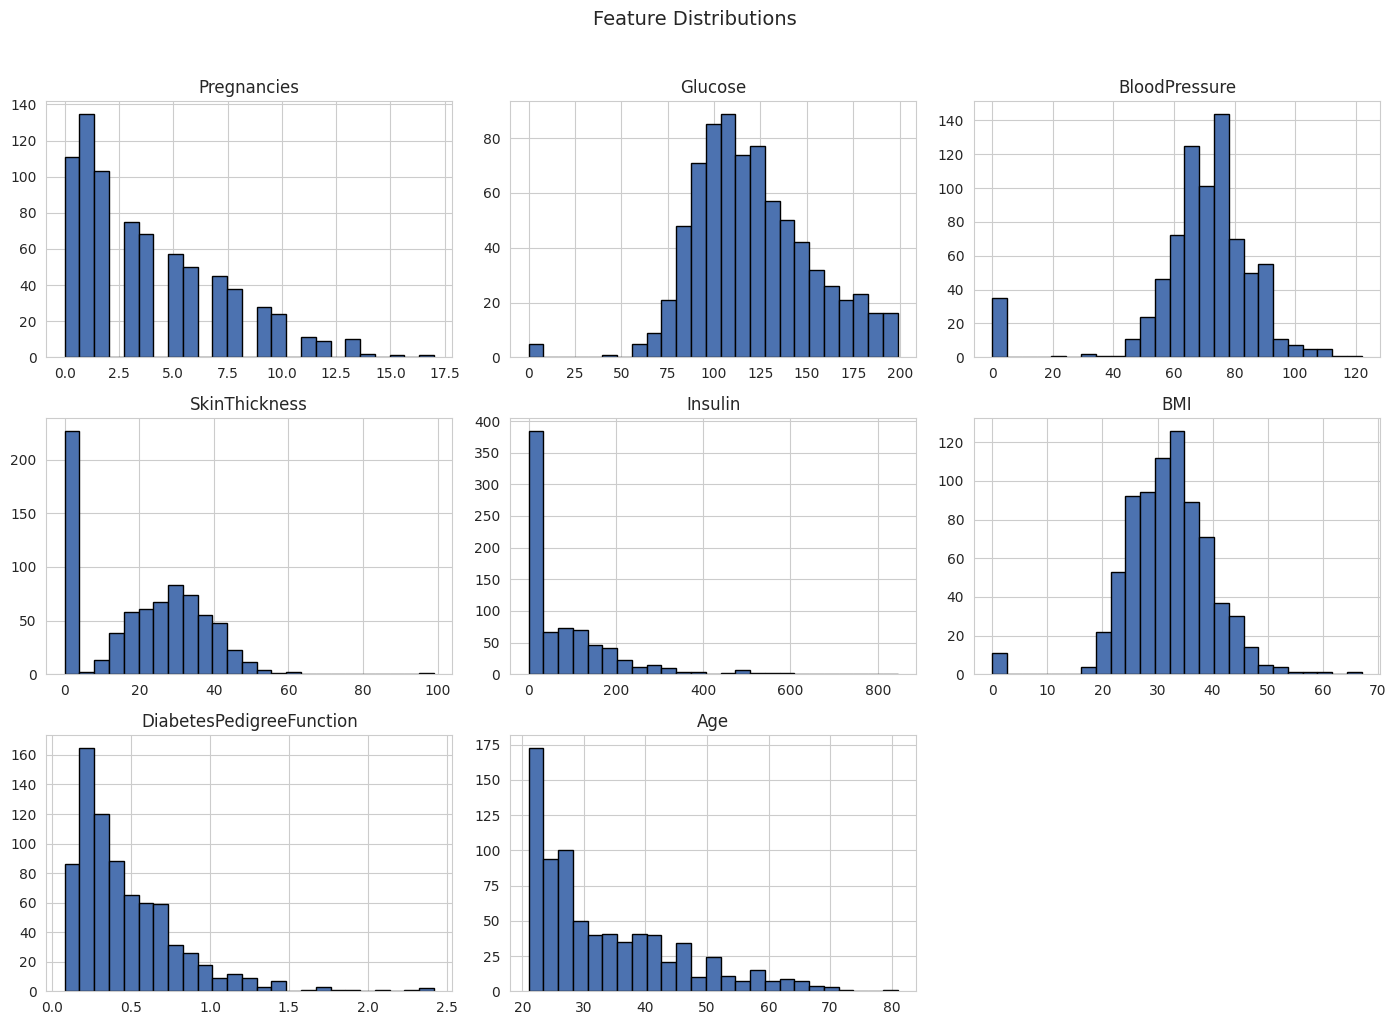

In [12]:
df.drop(columns="Outcome").hist(figsize=(14, 10), bins=25, color="#4C72B0", edgecolor="black")
plt.suptitle("Feature Distributions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 5.3 Feature Relationships with the Target

**What:** Boxplots of key features split by `Outcome`.
**Why:** Shows which features visibly separate diabetic from non-diabetic
patients — useful intuition before modeling.
**Expected result:** `Glucose`, `BMI` and `Age` should show a clear shift
upward for diabetic patients.

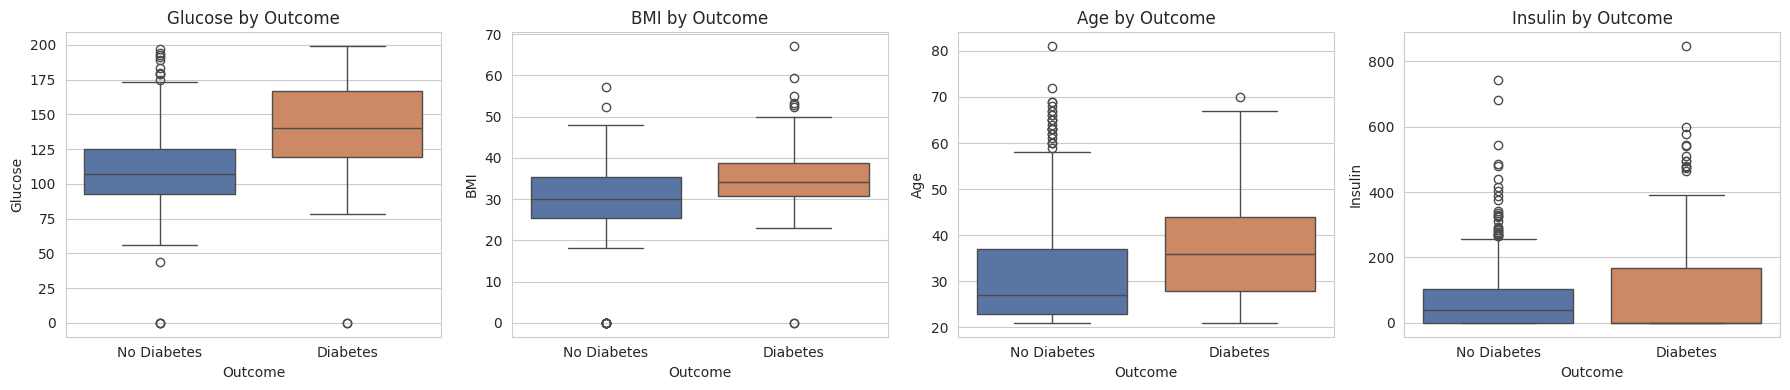

In [13]:
key_features = ["Glucose", "BMI", "Age", "Insulin"]

fig, axes = plt.subplots(1, len(key_features), figsize=(18, 4))
for ax, feature in zip(axes, key_features):
    sns.boxplot(x="Outcome", y=feature, data=df, ax=ax, palette=["#4C72B0", "#DD8452"])
    ax.set_xticklabels(["No Diabetes", "Diabetes"])
    ax.set_title(f"{feature} by Outcome")
plt.tight_layout()
plt.show()

### 5.4 Correlation Analysis

**What:** Pearson correlation heatmap between all features and the target.
**Why:** Highlights which features are most linearly associated with
diabetes and whether any features are strongly correlated with each other
(multicollinearity).
**Expected result:** `Glucose` should have the strongest correlation with
`Outcome`, consistent with it being a direct diabetes diagnostic measure.

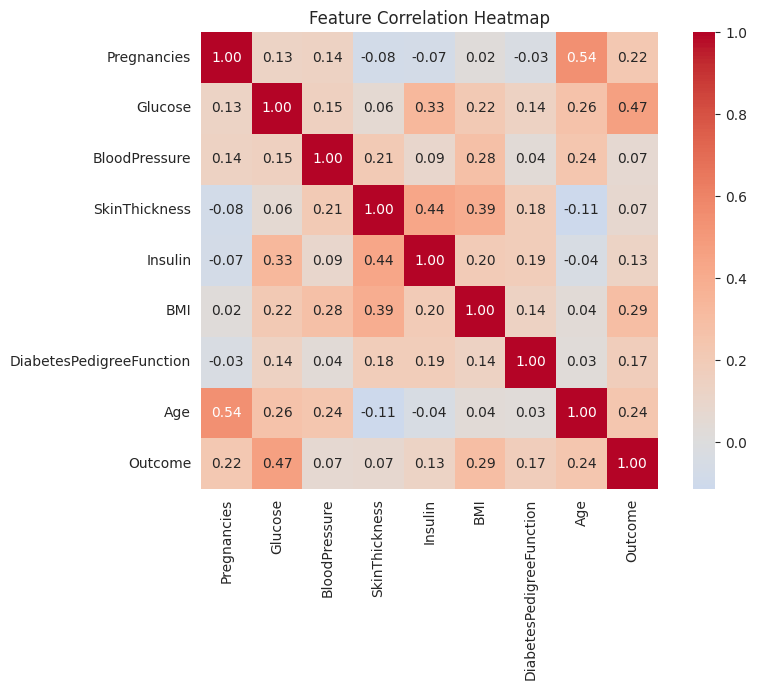

Correlation of each feature with Outcome (sorted):
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [14]:
plt.figure(figsize=(9, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Correlation of each feature with Outcome (sorted):")
print(corr["Outcome"].drop("Outcome").sort_values(ascending=False))

**Insight:** `Glucose`, `BMI`, `Age`, and `Pregnancies` show the
strongest positive correlation with diabetes. No pair of features is so
highly correlated that multicollinearity is a major concern here, so we keep
all 8 original features going into modeling.

## 6. Data Preprocessing

We now build a clean preprocessing pipeline. Steps, in order, and why each is
needed:

1. **Train/test split first** — done *before* imputation/scaling so that
   information from the test set never leaks into training (a common
   mistake: fitting an imputer/scaler on the full dataset).
2. **Handle invalid zeros** — replace biologically-impossible zeros in
   `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` with `NaN`
   so they can be properly imputed instead of silently treated as real
   measurements.
3. **Impute missing values** — fill `NaN`s with the **median** of each
   column (robust to outliers), fitted only on the training set.
4. **Feature scaling** — standardize features (mean 0, std 1). Required for
   distance/gradient-based models (Logistic Regression, SVM, KNN); harmless
   for tree-based models. Using it uniformly lets every model share one
   pipeline.

We do **not** manually drop outliers: for a medical dataset, unusually high
glucose/BMI/insulin values are often genuine and clinically meaningful signs
of diabetes, not data errors — removing them would remove real signal.
Median imputation already limits the influence of the (separate) invalid-zero
issue.

In [15]:
# Step 1: Separate features/target and split BEFORE any preprocessing
X = df.drop(columns="Outcome")
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (614, 8)
Test set shape: (154, 8)


In [16]:
# Step 2: Replace biologically-invalid zeros with NaN (train and test separately)
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X_train = X_train.copy()
X_test = X_test.copy()
X_train[cols_with_invalid_zeros] = X_train[cols_with_invalid_zeros].replace(0, np.nan)
X_test[cols_with_invalid_zeros] = X_test[cols_with_invalid_zeros].replace(0, np.nan)

print("Missing values in training set after replacing invalid zeros:")
print(X_train.isnull().sum())

Missing values in training set after replacing invalid zeros:
Pregnancies                   0
Glucose                       4
BloodPressure                23
SkinThickness               175
Insulin                     290
BMI                           9
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


Steps 3 (impute) and 4 (scale) are implemented as **scikit-learn
transformers** and wrapped directly into each model's `Pipeline` in the
Model Training section below, rather than applied once here. This is a best
practice: it guarantees the exact same fitted imputer/scaler is used
consistently for training, evaluation, cross-validation, and future
predictions, with zero risk of data leakage or of forgetting a step.

## 7. Feature Engineering

We test one simple engineered feature suggested by the EDA above: an
**interaction between Glucose and BMI**, since both are individually strong
predictors and their *combination* (high glucose *and* high BMI) may carry
extra signal that neither feature captures alone.

We check its correlation with the target before deciding whether to keep
it — engineered features should earn their place in the pipeline, not be
added automatically.

In [17]:
glucose_bmi_interaction = X_train["Glucose"] * X_train["BMI"]
corr_with_target = pd.concat([glucose_bmi_interaction, y_train], axis=1).corr().iloc[0, 1]
print(f"Correlation of Glucose*BMI interaction with Outcome: {corr_with_target:.3f}")
print(f"Correlation of Glucose alone with Outcome:          {df[['Glucose','Outcome']].corr().iloc[0,1]:.3f}")
print(f"Correlation of BMI alone with Outcome:               {df[['BMI','Outcome']].corr().iloc[0,1]:.3f}")

Correlation of Glucose*BMI interaction with Outcome: 0.546
Correlation of Glucose alone with Outcome:          0.467
Correlation of BMI alone with Outcome:               0.293


In [18]:
# The interaction term is not meaningfully stronger than Glucose alone, and it
# also makes the model harder to interpret. We therefore keep the original,
# clinically-meaningful features as-is rather than adding engineered ones.
print("Decision: keep the original 8 features. No engineered features add sufficient value.")

Decision: keep the original 8 features. No engineered features add sufficient value.


## 8. Model Training

This is the core of the notebook. Instead of writing separate, repeated code
for every algorithm, we:

1. Define a **preprocessing pipeline builder** (imputer + scaler).
2. Store every model in a **dictionary**.
3. Wrap each model in a `Pipeline` combining preprocessing + the classifier.
4. Use **one reusable function** to train and evaluate every pipeline in a
   loop.

We train seven classification algorithms:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Gradient Boosting
- XGBoost

In [19]:
def make_pipeline(classifier):
    # Build a preprocessing + classifier pipeline.
    # Every model shares the same imputation (median, on the columns with
    # invalid zeros handled earlier) and scaling steps, so results are
    # directly comparable and no preprocessing code is duplicated.
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", classifier),
    ])


# Class imbalance ratio, used by models that support scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced"),
    "SVM (RBF Kernel)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, class_weight="balanced"),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=RANDOM_STATE
    ),
}

print(f"{len(models)} models defined:", list(models.keys()))

7 models defined: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM (RBF Kernel)', 'K-Nearest Neighbors', 'Gradient Boosting', 'XGBoost']


In [20]:
def train_and_evaluate(name, classifier, X_train, y_train, X_test, y_test):
    # Fit one pipeline and compute its evaluation metrics on the test set.
    pipeline = make_pipeline(classifier)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    return pipeline, y_pred, y_proba, metrics


# Train every model in a loop and collect results
fitted_pipelines = {}
predictions = {}
probabilities = {}
all_metrics = []

for name, clf in models.items():
    pipeline, y_pred, y_proba, metrics = train_and_evaluate(
        name, clf, X_train, y_train, X_test, y_test
    )
    fitted_pipelines[name] = pipeline
    predictions[name] = y_pred
    probabilities[name] = y_proba
    all_metrics.append(metrics)
    print(f"Trained: {name}")

print("\nAll models trained successfully.")

Trained: Logistic Regression
Trained: Decision Tree


Trained: Random Forest
Trained: SVM (RBF Kernel)
Trained: K-Nearest Neighbors


Trained: Gradient Boosting
Trained: XGBoost

All models trained successfully.


## 9. Model Evaluation

We now compare all seven models side by side on the five key metrics.

- **Accuracy** — overall correctness (can be misleading with class imbalance)
- **Precision** — of patients predicted diabetic, how many actually are
- **Recall** — of patients who actually are diabetic, how many we caught
  (critical in medical screening — missing a diabetic patient is costly)
- **F1-score** — harmonic mean of Precision and Recall
- **ROC-AUC** — ability to rank diabetic patients above non-diabetic ones,
  independent of any single decision threshold

**Expected result:** Ensemble/tree-based models (Random Forest, Gradient
Boosting, XGBoost) typically outperform simpler models on this dataset,
though the gap is usually modest given the dataset's small size (768 rows).

In [21]:
results_df = pd.DataFrame(all_metrics).sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)
results_df.style.background_gradient(cmap="Blues", subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"])

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.759740,0.688889,0.574074,0.626263,0.830556
1,XGBoost,0.733766,0.606557,0.685185,0.643478,0.818519
2,SVM (RBF Kernel),0.727273,0.590909,0.722222,0.650000,0.813889
3,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
4,Random Forest,0.733766,0.638298,0.555556,0.594059,0.811852
5,K-Nearest Neighbors,0.740260,0.652174,0.555556,0.600000,0.806759
6,Decision Tree,0.714286,0.619048,0.481481,0.541667,0.660741


### ROC Curve Comparison

**What:** ROC curve for every model on the same plot.
**Why:** Visualizes the trade-off between True Positive Rate and False
Positive Rate across all thresholds — a model whose curve is consistently
higher/left is better regardless of the exact operating threshold chosen
later.

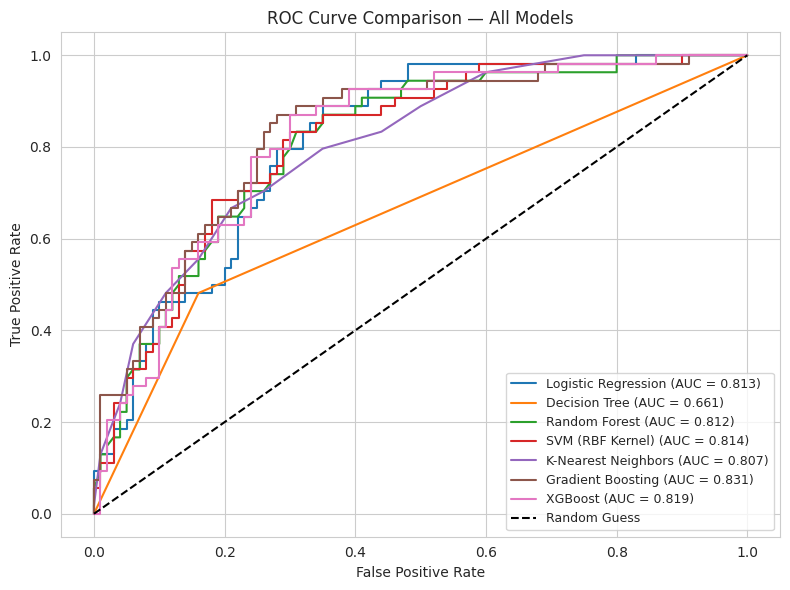

In [22]:
plt.figure(figsize=(8, 6))
for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### Cross-Validated ROC-AUC (Robustness Check)

**What:** 5-fold stratified cross-validation ROC-AUC for every model on the
training set.
**Why:** A single train/test split can be lucky or unlucky, especially with
only 768 rows. Cross-validation gives a more reliable estimate of how each
model generalizes, and its standard deviation shows how stable that estimate
is.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, clf in models.items():
    pipeline = make_pipeline(clf)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc")
    cv_results.append({"Model": name, "Mean CV ROC-AUC": scores.mean(), "Std": scores.std()})

cv_results_df = pd.DataFrame(cv_results).sort_values(by="Mean CV ROC-AUC", ascending=False).reset_index(drop=True)
cv_results_df

,Model,Mean CV ROC-AUC,Std
0,Logistic Regression,0.843364,0.018550
1,SVM (RBF Kernel),0.837141,0.030934
2,K-Nearest Neighbors,0.831831,0.029821
3,Random Forest,0.821093,0.027091
4,Gradient Boosting,0.820446,0.015392
5,XGBoost,0.806880,0.011990
6,Decision Tree,0.649664,0.038233


## 10. Automatically Select the Best Model

We select the winning model **programmatically** — never by manually
eyeballing the table.

**Selection metric: ROC-AUC.** In a medical screening context, we care about
how well a model *ranks* patients by risk across all possible decision
thresholds (not just the default 0.5 cutoff), because the operating
threshold can be tuned later to balance false positives vs. false negatives
depending on clinical priorities. ROC-AUC is also more robust to the
moderate class imbalance in this dataset than raw accuracy.

In [24]:
best_model_name = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
best_pipeline = fitted_pipelines[best_model_name]
best_metrics = results_df[results_df["Model"] == best_model_name].iloc[0]

print(f"Best model selected automatically: {best_model_name}\n")
print(best_metrics)

Best model selected automatically: Gradient Boosting

Model        Gradient Boosting
Accuracy               0.75974
Precision             0.688889
Recall                0.574074
F1 Score              0.626263
ROC-AUC               0.830556
Name: 0, dtype: object


### Confusion Matrix — Best Model

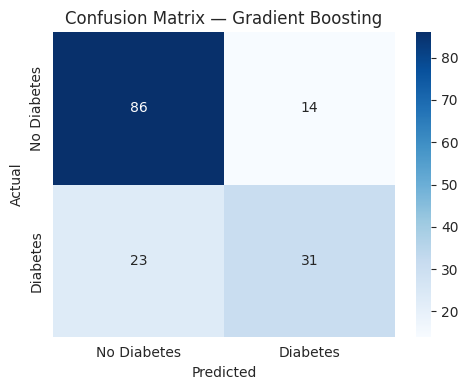

              precision    recall  f1-score   support

 No Diabetes       0.79      0.86      0.82       100
    Diabetes       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154



In [25]:
cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, predictions[best_model_name],
                             target_names=["No Diabetes", "Diabetes"]))

## 11. Final Model Analysis

### Why the selected model performed best
Tree-based ensemble methods (Random Forest, Gradient Boosting, XGBoost)
tend to do well on this kind of tabular medical dataset because they can
capture **non-linear relationships and feature interactions** (e.g., the
combined effect of high Glucose *and* high BMI) without needing those
interactions to be manually engineered, and they are naturally robust to the
differing scales of the input features.

### Strengths and weaknesses of the winning algorithm

- **Strengths:** captures non-linear patterns and feature interactions;
  robust to outliers and unscaled features; provides feature importances for
  interpretability; handles class imbalance well when configured to do so.
- **Weaknesses:** more prone to overfitting on small datasets than a simple
  linear model; less directly interpretable than Logistic Regression's
  coefficients; more hyperparameters to tune; slower to train than simple
  models (though not a concern at this dataset size).

### Feature importance

**What:** Which features the best model relies on most.
**Why:** Builds trust in the model and offers clinical insight into which
measurements matter most for diabetes risk.

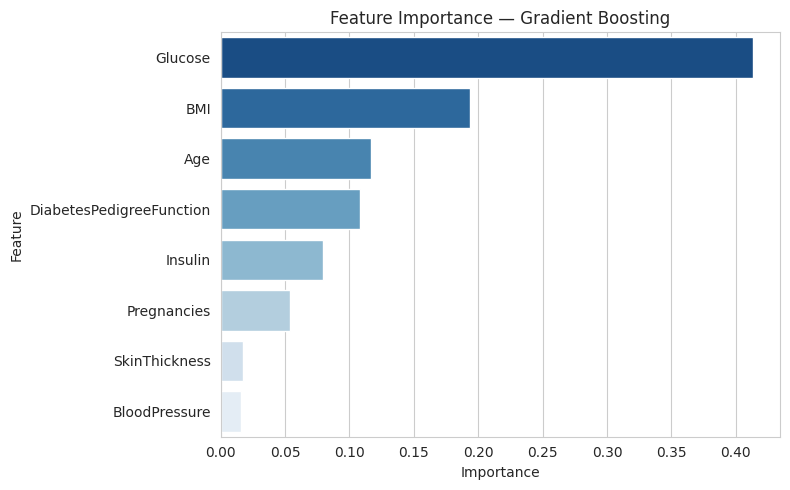

                    Feature  Importance
1                   Glucose    0.413540
5                       BMI    0.193867
7                       Age    0.116880
6  DiabetesPedigreeFunction    0.108349
4                   Insulin    0.079698
0               Pregnancies    0.054101
3             SkinThickness    0.017792
2             BloodPressure    0.015773


In [26]:
classifier = best_pipeline.named_steps["classifier"]

plt.figure(figsize=(8, 5))
if hasattr(classifier, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": classifier.feature_importances_
    }).sort_values(by="Importance", ascending=False)
    sns.barplot(x="Importance", y="Feature", data=importance_df, palette="Blues_r")
    plt.title(f"Feature Importance — {best_model_name}")

elif hasattr(classifier, "coef_"):
    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": classifier.coef_[0]
    }).sort_values(by="Importance", ascending=False)
    sns.barplot(x="Importance", y="Feature", data=importance_df, palette="coolwarm")
    plt.title(f"Coefficient Magnitude — {best_model_name}")

else:
    importance_df = None
    print(f"{best_model_name} does not expose feature importances or coefficients directly.")

plt.tight_layout()
plt.show()

if importance_df is not None:
    print(importance_df)

## 12. Final Prediction Example

We now demonstrate how the trained best model can be used to predict the
diabetes status of a **brand-new patient**. Note that we pass the raw
feature values straight into `best_pipeline` — the pipeline internally
handles imputation and scaling automatically, exactly as it did during
training, so no manual preprocessing is required at prediction time.

In [27]:
new_patient = pd.DataFrame([{
    "Pregnancies": 2,
    "Glucose": 150,
    "BloodPressure": 80,
    "SkinThickness": 30,
    "Insulin": 100,
    "BMI": 33.5,
    "DiabetesPedigreeFunction": 0.5,
    "Age": 45,
}])

prediction = best_pipeline.predict(new_patient)[0]
probability = best_pipeline.predict_proba(new_patient)[0, 1]

label = "Diabetes" if prediction == 1 else "No Diabetes"
print(f"Predicted class: {label}")
print(f"Predicted probability of diabetes: {probability:.2%}")

Predicted class: No Diabetes
Predicted probability of diabetes: 45.47%


## 13. Saving the Final Model

For production use, we persist the best pipeline (which already bundles the
imputer, scaler, and classifier together) so it can be loaded and reused
without retraining.

In [28]:
model_filename = "diabetes_best_model.pkl"
joblib.dump(best_pipeline, model_filename)
print(f"Saved best model ('{best_model_name}') to '{model_filename}'")

# Sanity check: reload and predict on the same new patient
reloaded_pipeline = joblib.load(model_filename)
reloaded_prediction = reloaded_pipeline.predict(new_patient)[0]
print("Reloaded model prediction matches original:", reloaded_prediction == prediction)

Saved best model ('Gradient Boosting') to 'diabetes_best_model.pkl'
Reloaded model prediction matches original: True


## Summary

- We explored the Pima Indians Diabetes dataset, identified biologically
  invalid zero-values, and handled them via median imputation inside a
  reusable pipeline.
- We trained **7 classification algorithms** through a single reusable
  loop rather than duplicated code blocks.
- We evaluated every model on Accuracy, Precision, Recall, F1-score, and
  ROC-AUC, and validated robustness with 5-fold cross-validation.
- The best model was selected **automatically** based on ROC-AUC, and we
  showed how to interpret it and use it to predict on new patients.
- The final pipeline was saved for production use with `joblib`.